In [47]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDA / understand feature distributions

In [3]:
# --------------------------------------------------
# 1. Define the dataset path
# --------------------------------------------------

data_set_path = (
    Path.home()
    / "Desktop"
    / "fighting-churn-learning"
    / "output"
    / "churn_dataset.csv"
)

print("Dataset:", data_set_path)
print("File exists:", data_set_path.exists())

Dataset: /Users/toor/Desktop/fighting-churn-learning/output/churn_dataset.csv
File exists: True


In [32]:
# --------------------------------------------------
# 2. Load and inspect the dataset
# --------------------------------------------------

churn_data = pd.read_csv(data_set_path)

churn_data["is_churn"] = (
    churn_data["is_churn"]
    .astype(str)
    .str.lower()
    .map({"true": 1, "false": 0, "t": 1, "f": 0})
)

churn_data.head()

,account_id,observation_date,is_churn,like_per_month,newfriend_per_month,post_per_month,adview_per_month,dislike_per_month,unfriend_per_month,message_per_month,reply_per_month,account_tenure
0,82,2020-02-09,0,101,0,0,0,0,0,0,0,24
1,122,2020-02-09,0,8,0,0,0,0,0,0,0,24
2,184,2020-02-09,0,12,0,0,0,0,0,0,0,24
3,262,2020-02-09,0,22,0,0,0,0,0,0,0,24
4,291,2020-02-09,0,18,0,0,0,0,0,0,0,24


In [5]:
feature_cols = [
    'like_per_month',
    'newfriend_per_month',
    'post_per_month',
    'adview_per_month',
    'dislike_per_month',
    'unfriend_per_month',
    'message_per_month',
    'reply_per_month',
    'account_tenure'
]

for col in feature_cols:
    print(
        col,
        "nonzero =", (df[col] != 0).sum(),
        "unique =", df[col].nunique(),
        "max =", df[col].max()
    )

like_per_month nonzero = 32781 unique = 1139 max = 7031
newfriend_per_month nonzero = 0 unique = 1 max = 0
post_per_month nonzero = 0 unique = 1 max = 0
adview_per_month nonzero = 0 unique = 1 max = 0
dislike_per_month nonzero = 0 unique = 1 max = 0
unfriend_per_month nonzero = 0 unique = 1 max = 0
message_per_month nonzero = 0 unique = 1 max = 0
reply_per_month nonzero = 0 unique = 1 max = 0
account_tenure nonzero = 32897 unique = 32 max = 114


In [35]:
# --------------------------------------------------
#  choose parameters
# --------------------------------------------------

metric_to_plot = "like_per_month"
ncohort = 10

In [36]:
# --------------------------------------------------
#  create cohorts
# --------------------------------------------------

groups = pd.qcut(
    churn_data[metric_to_plot],
    q=ncohort,
    duplicates="drop"
)

groups.head()

0     (73.0, 102.0]
1    (-0.001, 10.0]
2      (10.0, 18.0]
3      (18.0, 28.0]
4      (10.0, 18.0]
Name: like_per_month, dtype: category
Categories (10, interval[float64, right]): [(-0.001, 10.0] < (10.0, 18.0] < (18.0, 28.0] < (28.0, 39.0] ... (73.0, 102.0] < (102.0, 149.0] < (149.0, 255.0] < (255.0, 7031.0]]

In [37]:
# --------------------------------------------------
# calculate cohort statistics
# --------------------------------------------------

cohort_means = (
    churn_data
    .groupby(groups, observed=False)[metric_to_plot]
    .mean()
)

cohort_churns = (
    churn_data
    .groupby(groups, observed=False)["is_churn"]
    .mean()
)

plot_frame = pd.DataFrame({
    metric_to_plot: cohort_means.values,
    "churn_rate_pct": cohort_churns.values * 100
})

plot_frame

,like_per_month,churn_rate_pct
0,5.804208,4.936886
1,14.434727,2.861736
2,23.366917,1.876443
3,33.831421,1.625239
4,46.664540,1.306594
5,63.611720,1.629583
6,86.934568,1.523753
7,124.039531,1.389747
8,193.636364,1.189750
9,558.806718,1.038168


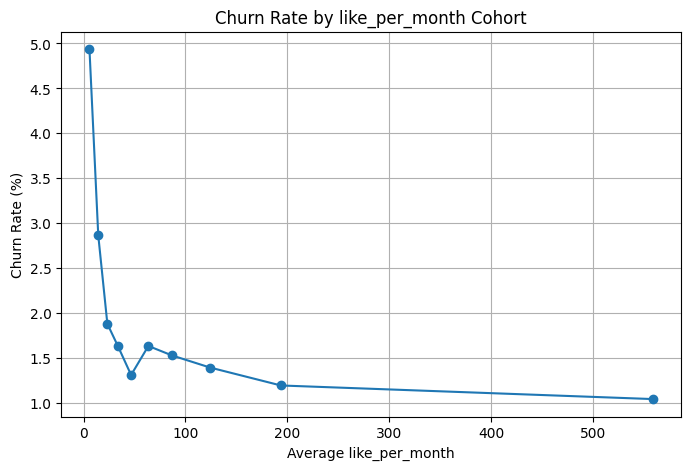

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    plot_frame[metric_to_plot],
    plot_frame["churn_rate_pct"],
    marker="o"
)

plt.xlabel("Average like_per_month")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by like_per_month Cohort")
plt.grid()
plt.show()

# transform skewed features + standardize them

In [43]:


# --------------------------------------------------
# 2. Define Listing 5.2 function
# --------------------------------------------------

def dataset_stats(data_set_path):

    #  Convert churn flag to numeric
    if "is_churn" in churn_data.columns:

        if churn_data["is_churn"].dtype == object:
            churn_data["is_churn"] = (
                churn_data["is_churn"]
                .astype(str)
                .str.lower()
                .map({
                    "true": 1.0,
                    "false": 0.0,
                    "t": 1.0,
                    "f": 0.0,
                    "1": 1.0,
                    "0": 0.0
                })
            )
        else:
            churn_data["is_churn"] = (
                churn_data["is_churn"]
                .astype(float)
            )

    # Keep only numeric columns for statistical calculations
    numeric_data = churn_data.select_dtypes(include="number")

    # ④ Standard descriptive statistics
    summary = numeric_data.describe()

    # ⑤ Put metrics in rows
    summary = summary.transpose()

    # ⑥ Skewness
    summary["skew"] = numeric_data.skew()

    # ⑦ 1st percentile
    summary["1%"] = numeric_data.quantile(q=0.01)

    # ⑧ 99th percentile
    summary["99%"] = numeric_data.quantile(q=0.99)

    # ⑨ Fraction of observations that are nonzero
    summary["nonzero"] = (
        numeric_data.ne(0).sum(axis=0)
        / numeric_data.shape[0]
    )

    # ⑩ Reorder columns
    summary = summary[
        [
            "count",
            "nonzero",
            "mean",
            "std",
            "skew",
            "min",
            "1%",
            "25%",
            "50%",
            "75%",
            "99%",
            "max"
        ]
    ]

    # Rename percentile symbols for CSV-friendly column names
    summary.columns = (
        summary.columns
        .str.replace("%", "pct", regex=False)
    )

    # Save summary
    save_path = str(data_set_path).replace(
        ".csv",
        "_summarystats.csv"
    )

    summary.to_csv(
        save_path,
        header=True
    )

    print(f"Saving results to:\n{save_path}")

    return summary


# --------------------------------------------------
# 3. Run the analysis
# --------------------------------------------------

summary = dataset_stats(
    data_set_path=str(data_set_path)
)


# --------------------------------------------------
# 4. Display results
# --------------------------------------------------

display(summary)

Saving results to:
/Users/toor/Desktop/fighting-churn-learning/output/churn_dataset_summarystats.csv


,count,nonzero,mean,std,skew,min,1pct,25pct,50pct,75pct,99pct,max
account_id,32897.0,0.999909,5893.682798,3458.361561,0.084416,0.0,114.0,2926.0,5836.0,8762.0,12749.04,13309.0
is_churn,32897.0,0.019607,0.019607,0.138646,6.930186,0.0,0.0,0.0,0.0,0.0,1.00,1.0
like_per_month,32897.0,0.996474,114.499498,220.410692,8.926996,0.0,2.0,23.0,54.0,122.0,1006.12,7031.0
newfriend_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
post_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
adview_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
dislike_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
unfriend_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
message_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
reply_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0


In [44]:

# --------------------------------------------------
# 3. Run the analysis
# --------------------------------------------------

summary = dataset_stats(
    data_set_path=str(data_set_path)
)


Saving results to:
/Users/toor/Desktop/fighting-churn-learning/output/churn_dataset_summarystats.csv


In [45]:


# --------------------------------------------------
# 4. Display results
# --------------------------------------------------

display(summary)

,count,nonzero,mean,std,skew,min,1pct,25pct,50pct,75pct,99pct,max
account_id,32897.0,0.999909,5893.682798,3458.361561,0.084416,0.0,114.0,2926.0,5836.0,8762.0,12749.04,13309.0
is_churn,32897.0,0.019607,0.019607,0.138646,6.930186,0.0,0.0,0.0,0.0,0.0,1.00,1.0
like_per_month,32897.0,0.996474,114.499498,220.410692,8.926996,0.0,2.0,23.0,54.0,122.0,1006.12,7031.0
newfriend_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
post_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
adview_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
dislike_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
unfriend_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
message_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0
reply_per_month,32897.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0


# remove impossible/bad observations

In [48]:

# --------------------------------------------------
# 2. Define metric scoring function
# --------------------------------------------------

def metric_scores(data_set_path, skew_thresh=4.0):


    # Convert churn target if necessary
    if "is_churn" in churn_data.columns:

        if churn_data["is_churn"].dtype == object:

            churn_data["is_churn"] = (
                churn_data["is_churn"]
                .astype(str)
                .str.lower()
                .map({
                    "true": 1.0,
                    "false": 0.0,
                    "t": 1.0,
                    "f": 0.0,
                    "1": 1.0,
                    "0": 0.0
                })
            )

        else:
            churn_data["is_churn"] = (
                churn_data["is_churn"]
                .astype(float)
            )

    # ③ Copy the dataset
    data_scores = churn_data.copy()

    # ④ Remove target before transforming/scaling features
    data_scores = data_scores.drop(
        columns=["is_churn"]
    )

    # Keep only numeric feature columns
    data_scores = data_scores.select_dtypes(
        include="number"
    )

    # ⑤ Path created by Listing 5.2
    stat_path = str(data_set_path).replace(
        ".csv",
        "_summarystats.csv"
    )

    # Make sure Listing 5.2 was run first
    assert os.path.isfile(stat_path), \
        "You must run Listing 5.2 first to generate summary statistics."

    # ⑥ Load summary statistics
    stats = pd.read_csv(
        stat_path,
        index_col=0
    )

    # ⑦ Remove churn target statistics
    if "is_churn" in stats.index:
        stats = stats.drop(
            index="is_churn"
        )

    # Keep only statistics corresponding to features
    stats = stats.loc[
        stats.index.intersection(data_scores.columns)
    ]

    # Reorder features to match stats
    data_scores = data_scores[
        stats.index
    ]

    # ⑧ Identify strongly right-skewed,
    # nonnegative metrics
    skewed_columns = (
        (stats["skew"] > skew_thresh)
        &
        (stats["min"] >= 0)
    )

    # ⑨ Keep only columns where condition is True
    skewed_columns = (
        skewed_columns[
            skewed_columns
        ]
    )

    print("Metrics receiving log1p transformation:")

    if len(skewed_columns) == 0:
        print("None")

    else:
        for col in skewed_columns.index:
            print(f" - {col}")

    # ⑩ Iterate through highly skewed features
    for col in skewed_columns.index:

        # ⑪ Apply log(1 + x)
        data_scores[col] = np.log1p(
            data_scores[col]
        )

        # ⑫ Recalculate mean and std
        # after the log transform
        stats.at[col, "mean"] = (
            data_scores[col].mean()
        )

        stats.at[col, "std"] = (
            data_scores[col].std()
        )

    # Protect against division by zero
    zero_std_columns = stats.index[
        stats["std"] == 0
    ]

    if len(zero_std_columns) > 0:

        print("\nDropping zero-variance metrics:")

        for col in zero_std_columns:
            print(f" - {col}")

        data_scores = data_scores.drop(
            columns=zero_std_columns
        )

        stats = stats.drop(
            index=zero_std_columns
        )

    # ⑬ Standardize each feature:
    # z = (x - mean) / std
    data_scores = (
        data_scores - stats["mean"]
    ) / stats["std"]

    # ⑭ Reattach target WITHOUT transforming it
    data_scores["is_churn"] = (
        churn_data["is_churn"]
    )

    # ⑮ Save scored dataset
    score_save_path = str(data_set_path).replace(
        ".csv",
        "_scores.csv"
    )

    data_scores.to_csv(
        score_save_path,
        header=True
    )

    print(
        f"\nSaving results to:\n"
        f"{score_save_path}"
    )

    return data_scores


# --------------------------------------------------
# 3. Run Listing 5.3
# --------------------------------------------------

data_scores = metric_scores(
    data_set_path=str(data_set_path),
    skew_thresh=4.0
)


# --------------------------------------------------
# 4. Inspect results
# --------------------------------------------------

print("\nShape:")
print(data_scores.shape)

print("\nFirst 5 rows:")
display(data_scores.head())

print("\nFeature means after scaling:")
display(
    data_scores
    .drop(columns="is_churn")
    .mean()
    .round(4)
)

print("\nFeature standard deviations after scaling:")
display(
    data_scores
    .drop(columns="is_churn")
    .std()
    .round(4)
)

Metrics receiving log1p transformation:
 - like_per_month

Dropping zero-variance metrics:
 - newfriend_per_month
 - post_per_month
 - adview_per_month
 - dislike_per_month
 - unfriend_per_month
 - message_per_month
 - reply_per_month

Saving results to:
/Users/toor/Desktop/fighting-churn-learning/output/churn_dataset_scores.csv

Shape:
(32897, 4)

First 5 rows:


,account_id,like_per_month,account_tenure,is_churn
0,-1.680473,0.516299,-1.235197,0.0
1,-1.668907,-1.429966,-1.235197,0.0
2,-1.650979,-1.135170,-1.235197,0.0
3,-1.628425,-0.677778,-1.235197,0.0
4,-1.620040,-0.830943,-1.235197,0.0



Feature means after scaling:


account_id        0.0
like_per_month   -0.0
account_tenure    0.0
dtype: float64


Feature standard deviations after scaling:


account_id        1.0
like_per_month    1.0
account_tenure    1.0
dtype: float64

# check relationships/correlation between features

In [54]:

# --------------------------------------------------
# Define invalid-observation removal function
# --------------------------------------------------

def remove_invalid(
    data_set_path,
    min_valid=None,
    max_valid=None
):

    # ① Check that the dataset exists
    assert os.path.isfile(data_set_path), \
        f'"{data_set_path}" is not a valid path'

    # ② Load dataset
    churn_data = pd.read_csv(
        data_set_path,
        index_col=[0, 1]
    )

    # ③ Make a copy so the original stays unchanged
    clean_data = churn_data.copy()

    original_rows = len(clean_data)

    # --------------------------------------------------
    # ④–⑥ Apply minimum-validity rules
    # --------------------------------------------------

    if min_valid is not None:

        if not isinstance(min_valid, dict):
            raise TypeError(
                "min_valid must be a dictionary, for example "
                "{'account_tenure': 0}"
            )

        for metric, minimum in min_valid.items():

            # ⑤ Check metric exists
            if metric in clean_data.columns:

                before = len(clean_data)

                # ⑥ Keep observations at or above minimum
                clean_data = clean_data[
                    clean_data[metric] >= minimum
                ]

                removed = before - len(clean_data)

                print(
                    f"{metric}: removed {removed:,} rows "
                    f"below {minimum}"
                )

            else:

                print(
                    f'Metric "{metric}" not found in '
                    f'dataset "{data_set_path}"'
                )

    # --------------------------------------------------
    # ⑦–⑧ Apply maximum-validity rules
    # --------------------------------------------------

    if max_valid is not None:

        if not isinstance(max_valid, dict):
            raise TypeError(
                "max_valid must be a dictionary, for example "
                "{'account_tenure': 1000}"
            )

        for metric, maximum in max_valid.items():

            # ⑤ Check metric exists
            if metric in clean_data.columns:

                before = len(clean_data)

                # ⑧ Keep observations at or below maximum
                clean_data = clean_data[
                    clean_data[metric] <= maximum
                ]

                removed = before - len(clean_data)

                print(
                    f"{metric}: removed {removed:,} rows "
                    f"above {maximum}"
                )

            else:

                print(
                    f'Metric "{metric}" not found in '
                    f'dataset "{data_set_path}"'
                )
    # --------------------------------------------------
    # ⑨ Save cleaned dataset
    # --------------------------------------------------

    clean_save_path = str(data_set_path).replace(
        ".csv",
        "_cleaned.csv"
    )

    clean_data.to_csv(
        clean_save_path,
        header=True
    )
    # --------------------------------------------------
    # Summary
    # --------------------------------------------------

    final_rows = len(clean_data)
    total_removed = original_rows - final_rows

    print("\nCleaning summary")
    print("----------------")
    print(f"Original rows : {original_rows:,}")
    print(f"Clean rows    : {final_rows:,}")
    print(f"Rows removed  : {total_removed:,}")

    if original_rows > 0:

        print(
            f"Removed pct   : "
            f"{100 * total_removed / original_rows:.2f}%"
        )

    print(
        f"\nSaving cleaned dataset to:\n"
        f"{clean_save_path}"
    )

    return clean_data

# --------------------------------------------------
# 3. Example run
# --------------------------------------------------

clean_data = remove_invalid(
    data_set_path=str(data_set_path),
    min_valid=None,
    max_valid=None
)
# --------------------------------------------------
# 4. Inspect result
# --------------------------------------------------

print("\nShape:")
print(clean_data.shape)

display(clean_data.head())




Cleaning summary
----------------
Original rows : 32,897
Clean rows    : 32,897
Rows removed  : 0
Removed pct   : 0.00%

Saving cleaned dataset to:
/Users/toor/Desktop/fighting-churn-learning/output/churn_dataset_cleaned.csv

Shape:
(32897, 10)


,,is_churn,like_per_month,newfriend_per_month,post_per_month,adview_per_month,dislike_per_month,unfriend_per_month,message_per_month,reply_per_month,account_tenure
account_id,observation_date,,,,,,,,,,
82,2020-02-09,f,101,0,0,0,0,0,0,0,24
122,2020-02-09,f,8,0,0,0,0,0,0,0,24
184,2020-02-09,f,12,0,0,0,0,0,0,0,24
262,2020-02-09,f,22,0,0,0,0,0,0,0,24
291,2020-02-09,f,18,0,0,0,0,0,0,0,24
